In [2]:
#Basic Inspection
import pandas as pd

df = pd.read_csv(r"C:\Users\rkpan\OneDrive\Desktop\healthcare_dataset.csv")

print(df.shape)


(55500, 15)


In [3]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [4]:

print(df.isnull().sum())

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64


In [5]:
#Fix Column Names
df.columns = df.columns.str.lower().str.replace(" ", "_")

In [6]:
#clean text columns
df['name'] = df['name'].str.title()
df['doctor'] = df['doctor'].str.title()
df['hospital'] = df['hospital'].str.title()
df['medical_condition'] = df['medical_condition'].str.title()

In [7]:
#convert date
df['date_of_admission'] = pd.to_datetime(df['date_of_admission'], dayfirst=True)
df['discharge_date'] = pd.to_datetime(df['discharge_date'], dayfirst=True)

In [8]:
#create new kpi's 
df['length_of_stay'] = (df['discharge_date'] - df['date_of_admission']).dt.days

In [9]:
#handle missing values
df.isnull().sum()

name                  0
age                   0
gender                0
blood_type            0
medical_condition     0
date_of_admission     0
doctor                0
hospital              0
insurance_provider    0
billing_amount        0
room_number           0
admission_type        0
discharge_date        0
medication            0
test_results          0
length_of_stay        0
dtype: int64

In [10]:
df = df.dropna()  

In [11]:
#remove duplicate
df = df.drop_duplicates()

In [12]:
#fix date type
df['billing_amount'] = df['billing_amount'].astype(float)
df['age'] = df['age'].astype(int)

In [13]:
#save clean data
df.to_csv("cleaned_healthcare_data.csv", index=False)

In [14]:
#Python EDA
#Load Clean Data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"cleaned_healthcare_data.csv")

In [15]:
print(df.describe())
print(df['medical_condition'].value_counts())

                age  billing_amount   room_number  length_of_stay
count  54966.000000    54966.000000  54966.000000    54966.000000
mean      51.535185    25544.306284    301.124404       15.499290
std       19.605661    14208.409711    115.223143        8.661471
min       13.000000    -2008.492140    101.000000        1.000000
25%       35.000000    13243.718638    202.000000        8.000000
50%       52.000000    25542.749145    302.000000       15.000000
75%       68.000000    37819.858157    401.000000       23.000000
max       89.000000    52764.276740    500.000000       30.000000
medical_condition
Arthritis       9218
Diabetes        9216
Hypertension    9151
Obesity         9146
Cancer          9140
Asthma          9095
Name: count, dtype: int64


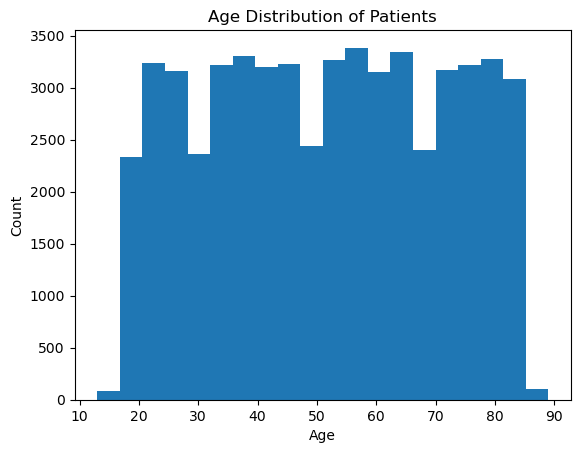

In [16]:
#Age Distribution
plt.hist(df['age'], bins=20)
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

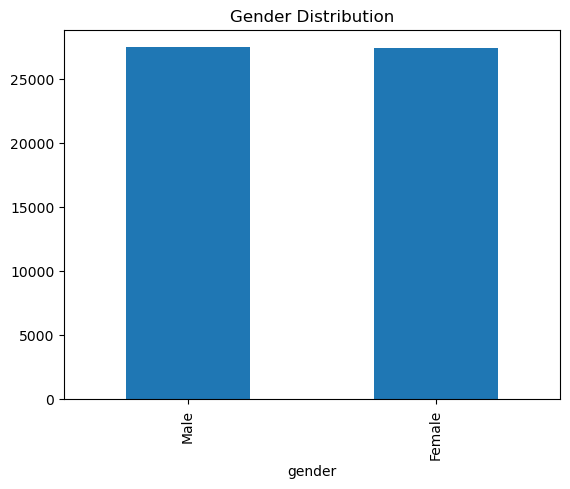

In [17]:
#Gender Distribution
df['gender'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.show()

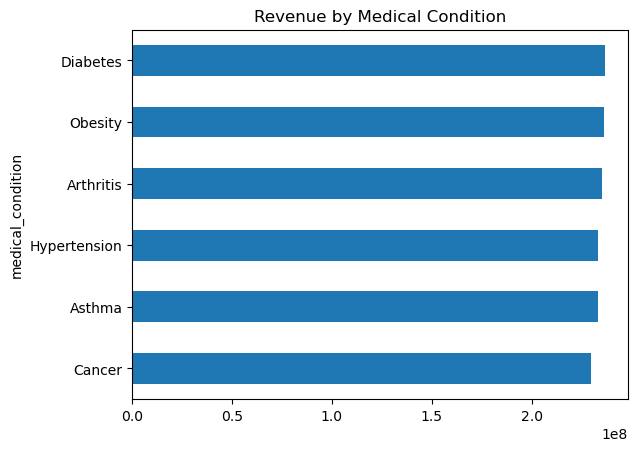

In [18]:
#Revenue by Medical Condition
df.groupby('medical_condition')['billing_amount'].sum().sort_values().plot(kind='barh')
plt.title("Revenue by Medical Condition")
plt.show()

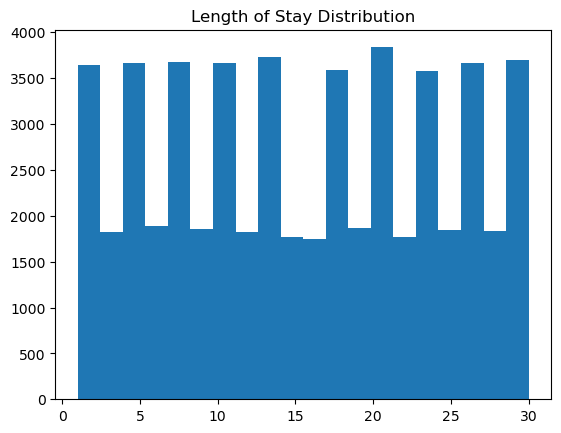

In [19]:
#Length of Stay Analysis
plt.hist(df['length_of_stay'], bins=20)
plt.title("Length of Stay Distribution")
plt.show()

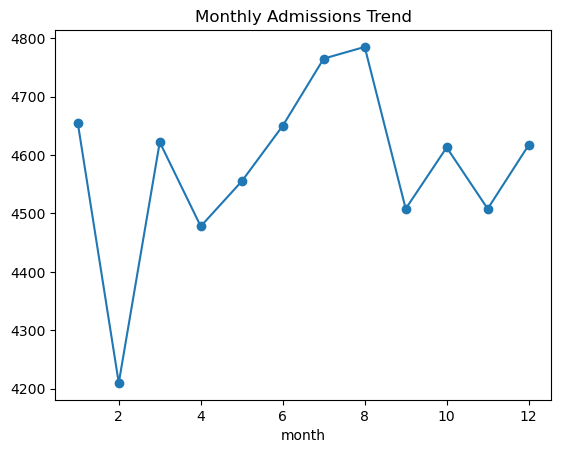

In [20]:
#Monthly Admissions Trend
df['date_of_admission'] = pd.to_datetime(df['date_of_admission'])

df['month'] = df['date_of_admission'].dt.month

df.groupby('month').size().plot(kind='line', marker='o')
plt.title("Monthly Admissions Trend")
plt.show()

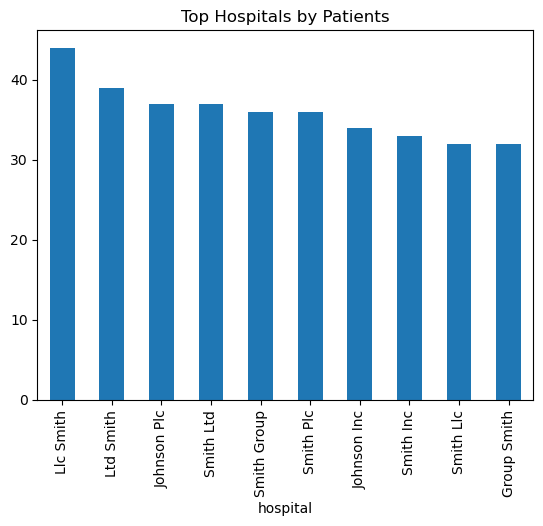

In [21]:
#Top Hospitals
df['hospital'].value_counts().head(10).plot(kind='bar')
plt.title("Top Hospitals by Patients")
plt.show()

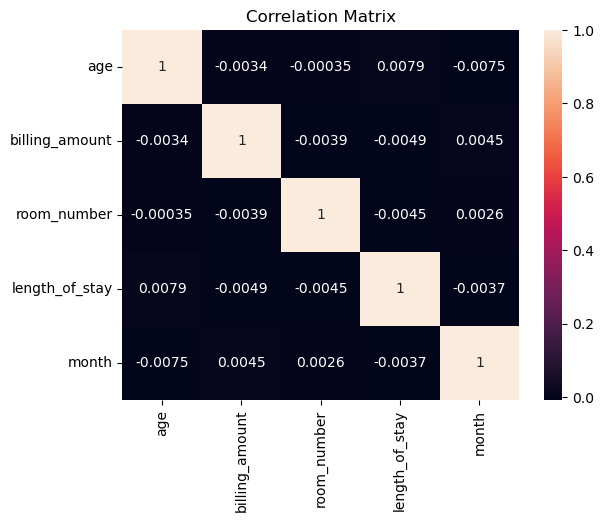

In [22]:
#Correlation Heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()